# SFT Training Pipeline — Qwen2.5-1.5B with QLoRA (Kaggle T4)

## Setup: Install compatible versions of bitsandbytes, transformers, peft, trl, accelerate

In [1]:
!pip install -q --force-reinstall --no-deps bitsandbytes==0.43.1

In [2]:
!pip install -q --force-reinstall --no-deps transformers==4.44.2

In [3]:
!pip install -q --force-reinstall --no-deps peft==0.12.0

In [4]:
!pip install -q --force-reinstall --no-deps trl==0.11.4

In [5]:
!pip install -q --force-reinstall --no-deps accelerate==0.34.2

In [6]:
!pip uninstall -y bitsandbytes
!pip install -U bitsandbytes

Found existing installation: bitsandbytes 0.43.1
Uninstalling bitsandbytes-0.43.1:
  Successfully uninstalled bitsandbytes-0.43.1
  Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl (60.7 MB)


In [7]:
!pip install -q 'accelerate>=1.1.0'

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.11.4 requires tyro>=0.5.11, which is not installed.


In [8]:
!pip install -q --force-reinstall transformers==4.44.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
trl 0.11.4 requires tyro>=0.5.11, which is not installed.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.3

## Verify installed library versions

In [9]:
import transformers, trl, peft, bitsandbytes, accelerate

print(f"transformers  : {transformers.__version__}")
print(f"trl           : {trl.__version__}")
print(f"peft          : {peft.__version__}")
print(f"bitsandbytes  : {bitsandbytes.__version__}")
print(f"accelerate    : {accelerate.__version__}")

transformers  : 4.44.2
trl           : 0.11.4
peft          : 0.12.0
bitsandbytes  : 0.49.2
accelerate    : 1.13.0


## Install liger-kernel (optional speed optimization, version-pinned for compatibility)

In [10]:
!pip install -q liger-kernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 10.2 MB/s eta 0:00:0000:01


In [11]:
!pip uninstall -y liger-kernel

Found existing installation: liger_kernel 0.8.0
Uninstalling liger_kernel-0.8.0:
  Successfully uninstalled liger_kernel-0.8.0


In [12]:
!pip install -q liger-kernel==0.3.1 transformers==4.44.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.0 MB/s eta 0:00:00


## Imports and GPU check

In [13]:
import torch
import json
from pathlib import Path
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainerCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

print(f"Torch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

2026-06-11 02:20:29.730530: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781144429.908911     231 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781144429.963397     231 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781144430.392299     231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781144430.392356     231 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781144430.392359     231 computation_placer.cc:177] computation placer alr

Torch: 2.10.0+cu128
CUDA available: True
  GPU 0: Tesla T4 — 15.6 GB
  GPU 1: Tesla T4 — 15.6 GB


## Configuration: model name, paths, LoRA hyperparameters, training hyperparameters

In [14]:
# ── Model ────────────────────────────────────────────────────────────────────
MODEL_NAME  = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR  = "/kaggle/working/sft_model"
DATA_PATH   = "/kaggle/input/your-dataset-folder/sft_train.jsonl"  # ← update this path to your Kaggle input path
MAX_LENGTH  = 512

# ── LoRA ─────────────────────────────────────────────────────────────────────
LORA_R          = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.05
LORA_TARGET     = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# ── Training ─────────────────────────────────────────────────────────────────
NUM_EPOCHS      = 3
BATCH_SIZE      = 2
GRAD_ACCUM      = 8
LR              = 2e-4
LR_SCHEDULER    = "cosine"
WARMUP_RATIO    = 0.05
WEIGHT_DECAY    = 0.01
MAX_GRAD_NORM   = 0.3

# ── Eval ─────────────────────────────────────────────────────────────────────
EVAL_SPLIT      = 0.05
EVAL_STEPS      = 50
SAVE_STEPS      = 100
LOGGING_STEPS   = 10

print("Config set")
print(f"  LoRA rank: {LORA_R}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Target modules: {LORA_TARGET}")

Config set
  LoRA rank: 16
  Epochs: 3
  Effective batch size: 16
  Target modules: ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']


## Inspect available Kaggle input files/paths

In [15]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sanidhyasrivastav67/sft-train/sft_train.jsonl


## Load SFT training dataset and preview

In [16]:
import json
import pandas as pd

def load_jsonl(file):
    with open(file) as f:
        return [json.loads(line) for line in f]

sft = pd.DataFrame(load_jsonl("/kaggle/input/datasets/sanidhyasrivastav67/sft-train/sft_train.jsonl"))
print(f"SFT shape: {sft.shape}")
print(f"Columns: {sft.columns.tolist()}")
print("\nSFT sample:")
display(sft.head())

SFT shape: (5000, 2)
Columns: ['prompt', 'response']

SFT sample:


,prompt,response
0,Your skies will be blue and filled with stars ...,"Your skies will be blue, and filled with stars..."
1,Instructions: The task is to generate text bas...,Task Explanation: The task is asking to genera...
2,"In this task, you will be presented with a pre...",This task is asking you to analyze the relatio...
3,Answer by taking a quote from the following ar...,The quote provided does not mention the specif...
4,Definition: Given a sequence of actions to nav...,"turn right, jump, turn right, jump, run twice"


## Function: load JSONL, format into chat template, split train/eval

In [17]:
def load_and_format_dataset(data_path, tokenizer, eval_split=0.05):
    raw = []
    with open(data_path) as f:
        for line in f:
            line = line.strip()
            if line:
                raw.append(json.loads(line))

    formatted = []
    for item in raw:
        # Build chat messages from your prompt/response fields
        messages = [
            {"role": "user",      "content": item["prompt"]},
            {"role": "assistant", "content": item["response"]}
        ]
        # Apply Qwen chat template
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )
        formatted.append({"text": text})

    dataset = Dataset.from_list(formatted)

    # Train / eval split
    split = dataset.train_test_split(test_size=eval_split, seed=42)
    print(f"Train samples : {len(split['train'])}")
    print(f"Eval  samples : {len(split['test'])}")
    print(f"\nSample formatted text (truncated):\n{split['train'][0]['text'][:300]}")
    return split["train"], split["test"]

## Load tokenizer and set pad token (Qwen2.5 uses eos as pad)

In [18]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

# Qwen2.5 uses eos as pad — keep consistent
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"   # required for SFTTrainer with causal LM

print(f"Vocab size    : {tokenizer.vocab_size}")
print(f"Pad token     : {tokenizer.pad_token}")
print(f"EOS token     : {tokenizer.eos_token}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size    : 151643
Pad token     : <|endoftext|>
EOS token     : <|im_end|>


## Apply formatting function to create train and eval datasets

In [19]:
train_dataset, eval_dataset = load_and_format_dataset("/kaggle/input/datasets/sanidhyasrivastav67/sft-train/sft_train.jsonl", tokenizer, EVAL_SPLIT)

Train samples : 4750
Eval  samples : 250

Sample formatted text (truncated):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
I am trying to decide whether it's worth it to invest in this film proposal. Can you help me answer a few questions? If you can't, please say "No I can't".  Question: Who paid Tyler to 


## Re-init tokenizer + check token length distribution of dataset

In [20]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token     = tokenizer.eos_token
tokenizer.padding_side  = "right"  

print(f"Vocab size:    {tokenizer.vocab_size}")
print(f"Pad token:     {tokenizer.pad_token}")
print(f"Padding side:  {tokenizer.padding_side}")

# quick token length check on the dataset
lengths = [len(tokenizer(s["text"], truncation=False)["input_ids"]) for s in train_dataset.select(range(200))]
print(f"\nToken length stats (first 200 samples):")
print(f"  min: {min(lengths)}")
print(f"  max: {max(lengths)}")
print(f"  avg: {sum(lengths)//len(lengths)}")
print(f"  over MAX_LENGTH ({MAX_LENGTH}): {sum(1 for l in lengths if l > MAX_LENGTH)}")

Vocab size:    151643
Pad token:     <|im_end|>
Padding side:  right

Token length stats (first 200 samples):
  min: 57
  max: 1485
  avg: 389
  over MAX_LENGTH (512): 55


## Configure 4-bit quantization (QLoRA) and load base model

In [21]:
# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit               = True,
    bnb_4bit_quant_type        = "nf4",
    bnb_4bit_compute_dtype     = torch.bfloat16,   
    bnb_4bit_use_double_quant  = True,             
)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config = bnb_config,
    device_map          = "auto",
    trust_remote_code   = True,
    torch_dtype         = torch.bfloat16,
)
model.config.use_cache = False                    
model.config.pretraining_tp = 1

# count total vs trainable params
total  = sum(p.numel() for p in model.parameters())
print(f"Model loaded")
print(f"Total params: {total/1e6:.1f}M")

Loading model...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded
Total params: 888.6M


## Prepare quantized model for k-bit (LoRA) training

In [22]:
from peft import prepare_model_for_kbit_training
model = prepare_model_for_kbit_training(model)
print("Model prepared for kbit training")

Model prepared for kbit training


## Apply LoRA adapters to model

In [23]:
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## Define SFTConfig (training hyperparameters, output dir, scheduler etc.)

In [24]:
sft_config = SFTConfig(
    # output
    output_dir                  = OUTPUT_DIR,

    # data
    max_seq_length              = MAX_LENGTH,
    dataset_text_field          = "text",         
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    gradient_checkpointing      = True,            

    # optimizer
    learning_rate               = LR,
    lr_scheduler_type           = LR_SCHEDULER,
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    max_grad_norm               = MAX_GRAD_NORM,
    optim                       = "paged_adamw_8bit",  
    # precision
    bf16                        = True,
    fp16                        = False,

    # eval & saving
    eval_strategy               = "steps",
    eval_steps                  = EVAL_STEPS,
    save_strategy               = "steps",
    save_steps                  = SAVE_STEPS,
    save_total_limit            = 2,              
    load_best_model_at_end      = True,           
    metric_for_best_model       = "eval_loss",

    # logging
    logging_steps               = LOGGING_STEPS,
    report_to                   = "none",

    # packing — off
    packing                     = False,
)

print("SFTConfig set")

SFTConfig set


## Custom callback to log train/eval loss during training

In [25]:
# simple callback to print train + eval loss at each eval step
# so you can see if model is converging without wandb
class LossLogger(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses  = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        step = state.global_step
        if "loss" in logs:
            self.train_losses.append((step, logs["loss"]))
            print(f"  Step {step:>4} | train_loss: {logs['loss']:.4f}", end="")
        if "eval_loss" in logs:
            self.eval_losses.append((step, logs["eval_loss"]))
            print(f"  |  eval_loss: {logs['eval_loss']:.4f}", end="")
        print()

loss_logger = LossLogger()
print("Callback ready")

Callback ready


## Initialize SFTTrainer and start training

In [26]:
trainer = SFTTrainer(
    model           = model,
    args            = sft_config,
    train_dataset   = train_dataset,
    eval_dataset    = eval_dataset,
    tokenizer       = tokenizer,
    callbacks       = [loss_logger],
)

print("Starting SFT training...")
print(f"  Total steps: {trainer.args.max_steps if trainer.args.max_steps > 0 else 'auto'}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Effective batch size: {BATCH_SIZE * GRAD_ACCUM}\n")

trainer.train()

print("\nTraining complete")

Map:   0%|          | 0/4750 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

Starting SFT training...
  Total steps: auto
  Epochs: 3
  Effective batch size: 16



/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such a

Step,Training Loss,Validation Loss
50,1.422800,1.482902
100,1.385400,1.458034
150,1.460400,1.445483
200,1.335300,1.438185
250,1.366000,1.432196
300,1.328900,1.428870
350,1.216700,1.436460
400,1.268000,1.432429
450,1.330700,1.431188
500,1.382100,1.426962


...

  Step  610 | train_loss: 1.2012
  Step  620 | train_loss: 1.1410
  Step  630 | train_loss: 1.1333
  Step  640 | train_loss: 1.1753
  Step  650 | train_loss: 1.1245
  |  eval_loss: 1.4469
  Step  660 | train_loss: 1.1012
  Step  670 | train_loss: 1.2450
  Step  680 | train_loss: 1.1394
  Step  690 | train_loss: 1.1760
  Step  700 | train_loss: 1.2536
  |  eval_loss: 1.4493


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  Step  710 | train_loss: 1.1378
  Step  720 | train_loss: 1.0623
  Step  730 | train_loss: 1.1551
  Step  740 | train_loss: 1.2760
  Step  750 | train_loss: 1.0970
  |  eval_loss: 1.4494
  Step  760 | train_loss: 1.1721
  Step  770 | train_loss: 1.1643
  Step  780 | train_loss: 1.0583
  Step  790 | train_loss: 1.1846
  Step  800 | train_loss: 1.1070
  |  eval_loss: 1.4510


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  Step  810 | train_loss: 1.1645
  Step  820 | train_loss: 1.2148
  Step  830 | train_loss: 1.0895
  Step  840 | train_loss: 1.1606
  Step  850 | train_loss: 1.2425
  |  eval_loss: 1.4509
  Step  860 | train_loss: 1.1790
  Step  870 | train_loss: 1.1334
  Step  880 | train_loss: 1.2717


Training complete


## Save trained LoRA adapter and tokenizer

In [27]:
# saves only the LoRA adapter — ~80-100MB, not the full model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

import os
size_mb = sum(os.path.getsize(os.path.join(OUTPUT_DIR, f))
              for f in os.listdir(OUTPUT_DIR)) / 1e6

print(f"Adapter saved to: {OUTPUT_DIR}")
print(f"Total size: {size_mb:.1f} MB")
print(f"Files: {os.listdir(OUTPUT_DIR)}")

Adapter saved to: /kaggle/working/sft_model
Total size: 85.4 MB
Files: ['special_tokens_map.json', 'checkpoint-500', 'tokenizer.json', 'tokenizer_config.json', 'checkpoint-888', 'vocab.json', 'merges.txt', 'adapter_model.safetensors', 'README.md', 'adapter_config.json', 'added_tokens.json', 'training_args.bin']


## Zip the saved adapter for download

In [28]:
import shutil

shutil.make_archive(
    base_name="/kaggle/working/sft_model_zip",
    format="zip",
    root_dir="/kaggle/working",
    base_dir="sft_model"   # sft_model hai, sft_output nahi
)

print("Saved → /kaggle/working/sft_model_zip.zip")

Saved → /kaggle/working/sft_model_zip.zip


## Evaluation: Base vs SFT model comparison setup

In [34]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# ── Config ────────────────────────────────────────────────────────────────────
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
OUTPUT_DIR = "/kaggle/working/sft_model"

# ── Your Custom Prompts (replace with your domain) ────────────────────────────
test_prompts = [
    # 1. Reading comprehension + reasoning (dataset ka core task)
    "Read the following and answer the question:\n\n"
    "A store sells apples for $2 each and oranges for $3 each. "
    "John buys 4 apples and 2 oranges. He pays with a $20 bill.\n\n"
    "Question: How much change does John receive? Show your reasoning step by step.",

    # 2. Explanation task (Orca style — 'explain like I'm 5')
    "Explain what gravity is and why it keeps us on the ground. "
    "Make sure your explanation is simple enough for a 10-year-old to understand.",

    # 3. Instruction following + logical reasoning
    "List three differences between renewable and non-renewable energy sources. "
    "For each difference, explain why it matters for the environment.",
]

# ── Load Tokenizer ─────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# ── Load Base Model ────────────────────────────────────────────────────────────
print("Loading BASE model...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
base_model.eval()
print("Base model loaded ✅")

# ── Load SFT (Fine-tuned) Model ────────────────────────────────────────────────
print("\nLoading SFT (fine-tuned) model...")
sft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
sft_model.eval()
print("SFT model loaded ✅")

# ── Inference Helper ───────────────────────────────────────────────────────────
def get_response(mdl, prompt, max_new_tokens=200):
    messages = [{"role": "user", "content": prompt}]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        outputs = mdl.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1,
        )
    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

# ── Side-by-Side Comparison ────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("         PROMPT  →  BASE MODEL  vs  SFT MODEL")
print("=" * 70)

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n🔷 Prompt {i}: {prompt}")
    print("-" * 70)

    # Base model — disable LoRA adapter temporarily
    with sft_model.disable_adapter():
        base_response = get_response(sft_model, prompt)

    # SFT model — LoRA adapter active
    sft_response = get_response(sft_model, prompt)

    print(f"🤖 BASE MODEL:\n{base_response}")
    print(f"\n✅ SFT MODEL:\n{sft_response}")
    print("=" * 70)

Loading BASE model...
Base model loaded ✅

Loading SFT (fine-tuned) model...
SFT model loaded ✅

         PROMPT  →  BASE MODEL  vs  SFT MODEL

🔷 Prompt 1: Read the following and answer the question:

A store sells apples for $2 each and oranges for $3 each. John buys 4 apples and 2 oranges. He pays with a $20 bill.

Question: How much change does John receive? Show your reasoning step by step.
----------------------------------------------------------------------
🤖 BASE MODEL:
To calculate how much change John receives, we need to follow these steps:

1. **Calculate the total cost of the apples:**
   - Each apple costs $2.
   - John buys 4 apples.
   \[
   \text{Cost of apples} = 4 \times 2 = \$8
   \]

2. **Calculate the total cost of the oranges:**
   - Each orange costs $3.
   - John buys 2 oranges.
   \[
   \text{Cost of oranges} = 2 \times 3 = \$6
   \]

3. **Add the costs together to find the total amount spent:**
   \[
   \text{Total amount spent} = \$8 + \$6 = \$14
   \]

4. *

In [35]:
import json
import os

# ── Find exact file ────────────────────────────────────────────────────────────
for root, dirs, files in os.walk("/kaggle/input/datasets/sanidhyasrivastav67/sft-test"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/sanidhyasrivastav67/sft-test/sft_test.jsonl


In [37]:
import json
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Load test data ─────────────────────────────────────────────────────────────
TEST_PATH = "/kaggle/input/datasets/sanidhyasrivastav67/sft-test/sft_test.jsonl"

test_data = []
with open(TEST_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            test_data.append(json.loads(line))

print(f"Total test samples loaded: {len(test_data)}")
print(f"\nSample keys: {test_data[0].keys()}")
print(f"\nSample prompt: {test_data[0]['prompt'][:200]}")
print(f"\nSample response: {test_data[0]['response'][:200]}")

Total test samples loaded: 100

Sample keys: dict_keys(['prompt', 'response'])

Sample prompt: Question: What are Liza and Professor Evans surveying? If there is no answer, please output "Insufficient information to provide an answer.". Movie title: Demonia Context: Sicily, 1486. A mob of villa

Sample response: Liza and Professor Evans are surveying Ancient Greek ruins on a site near the small town of Santa Rosalia, Sicily. They are accompanied by a team of assistants who are supposed to be helping with the 


In [38]:
# ── Inference helper ───────────────────────────────────────────────────────────
def get_response(prompt, use_sft=True, max_new_tokens=200):
    if use_sft:
        sft_model.disable_adapter()
        sft_model.enable_adapter()   # SFT (LoRA active)
        mdl = sft_model
    else:
        mdl = sft_model              # will use disable_adapter context below

    messages   = [{"role": "user", "content": prompt}]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(mdl.device)

    if use_sft:
        with torch.no_grad():
            outputs = mdl.generate(
                **inputs,
                max_new_tokens    = max_new_tokens,
                temperature       = 0.7,
                top_p             = 0.9,
                do_sample         = True,
                pad_token_id      = tokenizer.eos_token_id,
                repetition_penalty= 1.1,
            )
    else:
        with torch.no_grad(), sft_model.disable_adapter():
            outputs = mdl.generate(
                **inputs,
                max_new_tokens    = max_new_tokens,
                temperature       = 0.7,
                top_p             = 0.9,
                do_sample         = True,
                pad_token_id      = tokenizer.eos_token_id,
                repetition_penalty= 1.1,
            )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


# ── Similarity score (TF-IDF cosine) ──────────────────────────────────────────
def similarity_score(generated, reference):
    vectorizer = TfidfVectorizer()
    try:
        tfidf = vectorizer.fit_transform([generated, reference])
        score = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
    except:
        score = 0.0
    return round(float(score), 4)


print("Functions ready ✅")

Functions ready ✅


In [40]:
# ── Install dependencies ───────────────────────────────────────────────────────
!pip install -q sentence-transformers

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [41]:
from sentence_transformers import SentenceTransformer, util
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm.auto import tqdm
import numpy as np
import torch

# ── Load Sentence Embedder ─────────────────────────────────────────────────────
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Embedder loaded ✅")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedder loaded ✅


In [42]:
# ── Load Base Model ────────────────────────────────────────────────────────────
BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

base_tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_NAME,
    trust_remote_code=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype   = torch.bfloat16,
    device_map    = "auto",
    trust_remote_code = True
)

base_model.eval()
print("Base model loaded ✅")

Base model loaded ✅


In [43]:
# ── SFT model already trained — just rename for clarity ───────────────────────
sft_model     = model        # your trained LoRA model
sft_tokenizer = tokenizer    # your tokenizer

sft_model.eval()
print("SFT model ready ✅")

SFT model ready ✅


In [44]:
# ── Generation Function ────────────────────────────────────────────────────────
def generate_response(mdl, tok, prompt):
    messages   = [{"role": "user", "content": prompt}]
    input_text = tok.apply_chat_template(
        messages,
        tokenize            = False,
        add_generation_prompt = True
    )
    inputs = tok(
        input_text,
        return_tensors = "pt",
        truncation     = True,
        max_length     = MAX_LENGTH
    ).to(mdl.device)

    with torch.no_grad():
        outputs = mdl.generate(
            **inputs,
            max_new_tokens     = 150,
            do_sample          = True,
            temperature        = 0.7,
            top_p              = 0.9,
            pad_token_id       = tok.eos_token_id,
            repetition_penalty = 1.1
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True)

print("Generate function ready ✅")

Generate function ready ✅


In [45]:
# ── Win Rate Evaluation Loop ───────────────────────────────────────────────────
base_scores = []
sft_scores  = []
wins   = 0
losses = 0
ties   = 0

print(f"Evaluating {len(test_data)} samples...")
print("This takes around 15-20 mins\n")

for idx, sample in enumerate(tqdm(test_data)):

    prompt    = sample["prompt"]
    reference = sample["response"]   # ground truth

    # ── Generate responses ─────────────────────────────────────────────────────
    base_resp = generate_response(base_model, base_tokenizer, prompt)
    sft_resp  = generate_response(sft_model,  sft_tokenizer,  prompt)

    # ── Embeddings ─────────────────────────────────────────────────────────────
    ref_emb  = embedder.encode(reference, convert_to_tensor=True)
    base_emb = embedder.encode(base_resp, convert_to_tensor=True)
    sft_emb  = embedder.encode(sft_resp,  convert_to_tensor=True)

    # ── Cosine Similarity ──────────────────────────────────────────────────────
    base_sim = util.cos_sim(ref_emb, base_emb).item()
    sft_sim  = util.cos_sim(ref_emb, sft_emb).item()

    base_scores.append(base_sim)
    sft_scores.append(sft_sim)

    # ── Win / Loss / Tie ───────────────────────────────────────────────────────
    if sft_sim > base_sim:
        wins   += 1
    elif base_sim > sft_sim:
        losses += 1
    else:
        ties   += 1

    # ── Progress every 10 samples ──────────────────────────────────────────────
    if (idx + 1) % 10 == 0:
        print(f"\nProcessed {idx+1}/{len(test_data)}")
        print(f"  Avg SFT  Score : {np.mean(sft_scores):.4f}")
        print(f"  Avg BASE Score : {np.mean(base_scores):.4f}")
        print(f"  SFT Wins so far: {wins} | Base Wins: {losses} | Ties: {ties}")

print("\nEvaluation complete! ✅")

Evaluating 100 samples...
This takes around 15-20 mins



  0%|          | 0/100 [00:00<?, ?it/s]


Processed 10/100
  Avg SFT  Score : 0.6381
  Avg BASE Score : 0.5591
  SFT Wins so far: 3 | Base Wins: 7 | Ties: 0

Processed 20/100
  Avg SFT  Score : 0.6019
  Avg BASE Score : 0.6144
  SFT Wins so far: 7 | Base Wins: 13 | Ties: 0

Processed 30/100
  Avg SFT  Score : 0.6189
  Avg BASE Score : 0.6025
  SFT Wins so far: 11 | Base Wins: 19 | Ties: 0

Processed 40/100
  Avg SFT  Score : 0.6351
  Avg BASE Score : 0.6252
  SFT Wins so far: 16 | Base Wins: 24 | Ties: 0

Processed 50/100
  Avg SFT  Score : 0.6362
  Avg BASE Score : 0.6331
  SFT Wins so far: 21 | Base Wins: 29 | Ties: 0

Processed 60/100
  Avg SFT  Score : 0.6386
  Avg BASE Score : 0.6374
  SFT Wins so far: 25 | Base Wins: 35 | Ties: 0

Processed 70/100
  Avg SFT  Score : 0.6425
  Avg BASE Score : 0.6436
  SFT Wins so far: 28 | Base Wins: 42 | Ties: 0

Processed 80/100
  Avg SFT  Score : 0.6505
  Avg BASE Score : 0.6558
  SFT Wins so far: 30 | Base Wins: 50 | Ties: 0

Processed 90/100
  Avg SFT  Score : 0.6504
  Avg BASE Scor

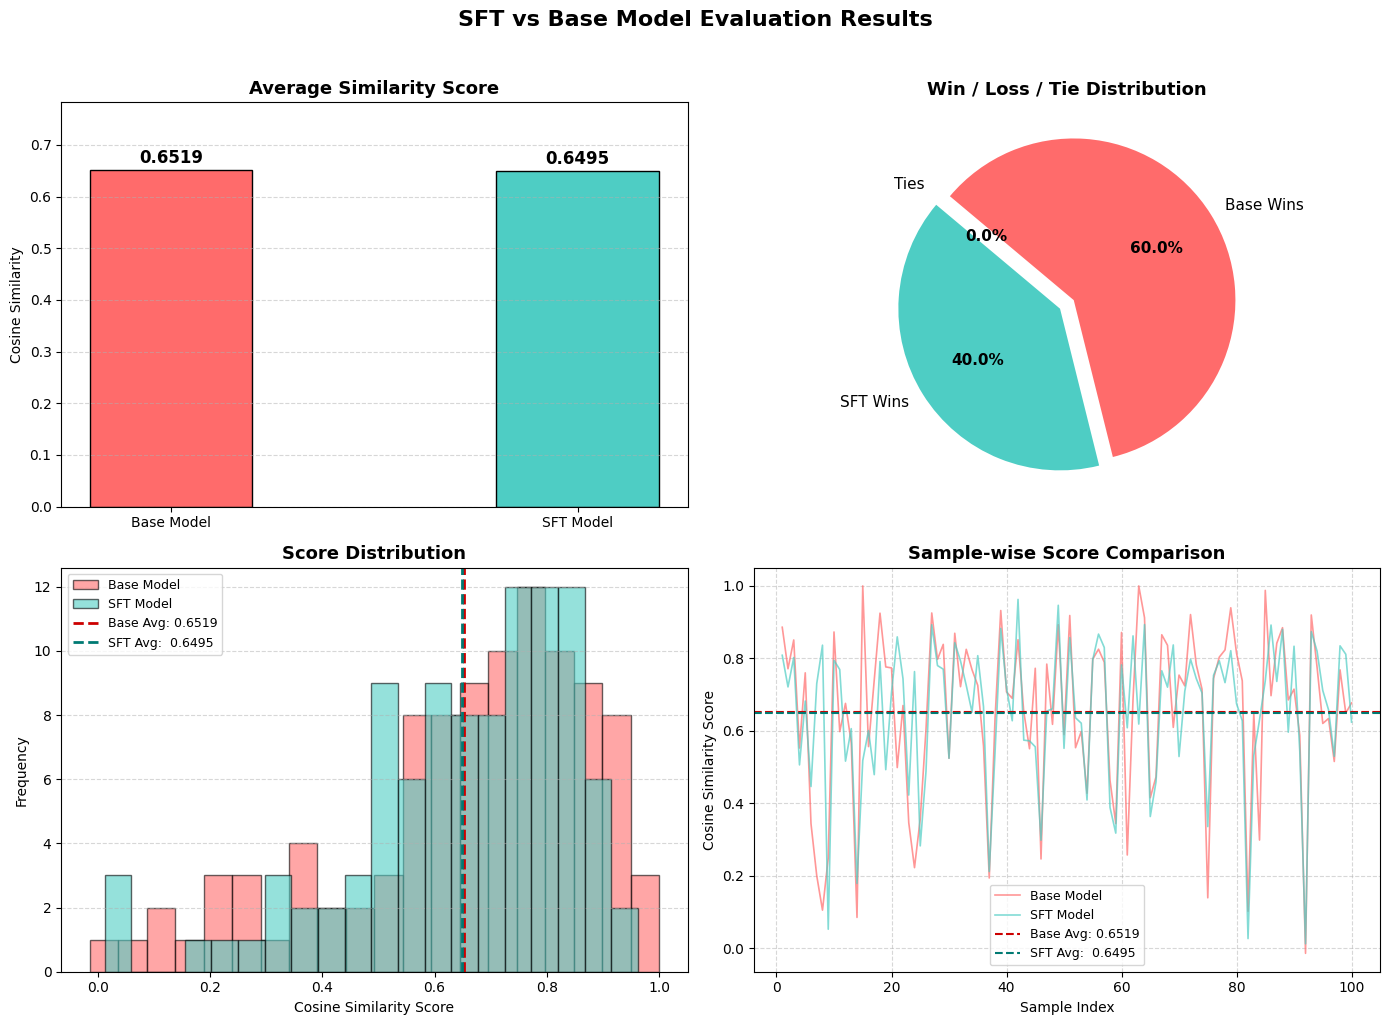

Graph saved ✅ → /kaggle/working/evaluation_results.png

          FINAL RESULTS SUMMARY
  Base Model Similarity : 0.6519
  SFT  Model Similarity : 0.6495
  Improvement           : -0.37%

  SFT  Wins  : 40
  Base Wins  : 60
  Ties       : 0
  Win Rate   : 40.00%

❌ Base model is performing better — consider more training.


In [47]:
# ── Graphical Representation ───────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("SFT vs Base Model Evaluation Results", fontsize=16, fontweight="bold", y=1.02)

# ── Plot 1: Average Similarity Score Bar Chart ─────────────────────────────────
ax1 = axes[0, 0]
models      = ["Base Model", "SFT Model"]
avg_scores  = [avg_base, avg_sft]
colors      = ["#FF6B6B", "#4ECDC4"]
bars        = ax1.bar(models, avg_scores, color=colors, width=0.4, edgecolor="black")

for bar, score in zip(bars, avg_scores):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center", va="bottom", fontweight="bold", fontsize=12
    )

ax1.set_title("Average Similarity Score", fontsize=13, fontweight="bold")
ax1.set_ylabel("Cosine Similarity")
ax1.set_ylim(0, max(avg_scores) * 1.2)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# ── Plot 2: Win / Loss / Tie Pie Chart ────────────────────────────────────────
ax2 = axes[0, 1]
pie_labels  = ["SFT Wins", "Base Wins", "Ties"]
pie_values  = [wins, losses, ties]
pie_colors  = ["#4ECDC4", "#FF6B6B", "#FFE66D"]
explode     = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax2.pie(
    pie_values,
    labels      = pie_labels,
    colors      = pie_colors,
    explode     = explode,
    autopct     = "%1.1f%%",
    startangle  = 140,
    textprops   = {"fontsize": 11}
)
for autotext in autotexts:
    autotext.set_fontweight("bold")

ax2.set_title("Win / Loss / Tie Distribution", fontsize=13, fontweight="bold")

# ── Plot 3: Score Distribution (Histogram) ────────────────────────────────────
ax3 = axes[1, 0]
ax3.hist(base_scores, bins=20, alpha=0.6, color="#FF6B6B", label="Base Model", edgecolor="black")
ax3.hist(sft_scores,  bins=20, alpha=0.6, color="#4ECDC4", label="SFT Model",  edgecolor="black")
ax3.axvline(avg_base, color="#CC0000", linestyle="--", linewidth=2, label=f"Base Avg: {avg_base:.4f}")
ax3.axvline(avg_sft,  color="#007A73", linestyle="--", linewidth=2, label=f"SFT Avg:  {avg_sft:.4f}")
ax3.set_title("Score Distribution", fontsize=13, fontweight="bold")
ax3.set_xlabel("Cosine Similarity Score")
ax3.set_ylabel("Frequency")
ax3.legend(fontsize=9)
ax3.grid(axis="y", linestyle="--", alpha=0.5)

# ── Plot 4: Sample-wise Score Line Chart ──────────────────────────────────────
ax4 = axes[1, 1]
x = range(1, len(base_scores) + 1)
ax4.plot(x, base_scores, color="#FF6B6B", alpha=0.7, linewidth=1.2, label="Base Model")
ax4.plot(x, sft_scores,  color="#4ECDC4", alpha=0.7, linewidth=1.2, label="SFT Model")
ax4.axhline(avg_base, color="#CC0000", linestyle="--", linewidth=1.5, label=f"Base Avg: {avg_base:.4f}")
ax4.axhline(avg_sft,  color="#007A73", linestyle="--", linewidth=1.5, label=f"SFT Avg:  {avg_sft:.4f}")
ax4.set_title("Sample-wise Score Comparison", fontsize=13, fontweight="bold")
ax4.set_xlabel("Sample Index")
ax4.set_ylabel("Cosine Similarity Score")
ax4.legend(fontsize=9)
ax4.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("/kaggle/working/evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved ✅ → /kaggle/working/evaluation_results.png")

# ── Final Summary Box ──────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("          FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"  Base Model Similarity : {avg_base:.4f}")
print(f"  SFT  Model Similarity : {avg_sft:.4f}")
print(f"  Improvement           : {improvement:.2f}%")
print()
print(f"  SFT  Wins  : {wins}")
print(f"  Base Wins  : {losses}")
print(f"  Ties       : {ties}")
print(f"  Win Rate   : {win_rate:.2%}")
print("=" * 50)

if win_rate >= 0.55:
    print("\n✅ SFT model is BETTER than base model!")
elif win_rate >= 0.45:
    print("\n⚠️  Models are roughly EQUAL.")
else:
    print("\n❌ Base model is performing better — consider more training.")